# XAI Pipeline – Usage Guide
### FusionModel (xresnet1d101 + MetaMLP) — PTB-XL

**Methods covered:**
| Scope | Method | Branch |
|---|---|---|
| Local ECG | LRP | xresnet1d101 |
| ECG validation | DTD | xresnet1d101 |
| Optional/qualitative | Grad-CAM | xresnet1d101 |
| Local metadata | SHAP | MetaMLP |
| Global | PFI | Full model |

## 0. Install dependencies

In [27]:
# Run once
!pip install zennit shap

## 1. Imports & setup

In [28]:
import sys, torch, numpy as np
sys.path.insert(0, '..')   # project root

from models.xresnet1d   import build_xresnet1d101
from models.meta_mlp    import MetaMLP
from models.fusion      import FusionModel
from utils.data_loader  import load_ptbxl, load_metadata, FusionDataset
from xai_pipeline       import XAIPipeline
from sklearn.metrics    import roc_auc_score
from torch.utils.data   import DataLoader

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
PATH       = r"C:/Users/inaki/Desktop/TFG/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"        # PTB-XL root
CKPT       = '../outputs/best_fusion_model.pt'
SR         = 100               # sampling rate
NUM_CLASSES = 5                # NORM, MI, STTC, CD, HYP

META_COLS  = ['age','sex','height','weight','nurse','site','device',
              'year','month','weekday']
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
CLASS_NAMES= ['NORM','MI','STTC','CD','HYP']

print('Device:', DEVICE)

Device: cuda


## 2. Load data

In [29]:
import pandas as pd, ast, os
from sklearn.preprocessing import MultiLabelBinarizer

X_train, X_val, X_test, y_train, y_val, y_test, classes = load_ptbxl(PATH, SR)

# Load full CSV for metadata
Y_full = pd.read_csv(os.path.join(PATH, 'ptbxl_database.csv'), index_col='ecg_id')
Y_full.scp_codes = Y_full.scp_codes.apply(ast.literal_eval)

meta_all = load_metadata(Y_full)

# Split metadata by fold
train_mask = Y_full.strat_fold.isin(range(1, 9))
val_mask   = Y_full.strat_fold == 9
test_mask  = Y_full.strat_fold == 10

meta_train = meta_all[train_mask].reset_index(drop=True)
meta_val   = meta_all[val_mask].reset_index(drop=True)
meta_test  = meta_all[test_mask].reset_index(drop=True)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Classes: {classes}')

Train: (17418, 1000, 12)  Val: (2183, 1000, 12)  Test: (2198, 1000, 12)
Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']


## 3. Rebuild & load trained model

In [30]:
import torch.nn as nn

ecg_model  = build_xresnet1d101(num_classes=NUM_CLASSES, input_channels=12, device=DEVICE)
meta_model = MetaMLP(in_features=len(META_COLS), hidden=64, out_features=32).to(DEVICE)
fusion     = FusionModel(ecg_model, meta_model, num_classes=NUM_CLASSES).to(DEVICE)

# Sanity check — should print 37
dummy_ecg  = torch.zeros(2, 12, 1000).to(DEVICE)
dummy_meta = torch.zeros(2, len(META_COLS)).to(DEVICE)
with torch.no_grad():
    out = fusion(dummy_ecg, dummy_meta)
print("Fusion dim:", fusion.classifier[0].weight.shape[1])  # 37
print("Output shape:", out.shape)                            # (2, 5)

# Load weights
fusion.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=False))
fusion.eval()
print('Model loaded.')

Fusion dim: 37
Output shape: torch.Size([2, 5])
Model loaded.


## 4. Initialise XAI pipeline

In [31]:
xai = XAIPipeline(
    fusion_model = fusion,
    device       = DEVICE,
    class_names  = CLASS_NAMES,
    meta_cols    = META_COLS,
    lead_names   = LEAD_NAMES,
    n_pfi_repeats= 5,
)
print('XAI pipeline ready.')

XAI pipeline ready.


---
## 5. ECG XAI
### 5.1 LRP  –  Layer-wise Relevance Propagation

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from zennit.composites import EpsilonPlusFlat
from zennit.attribution import Gradient
from models.xresnet1d import xresnet1d101

# ── Load standalone ECG model ────────────────────────────────────────
ecg_only = xresnet1d101(input_channels=12, num_classes=5).to(DEVICE)
ecg_only.load_state_dict(torch.load('../outputs/best_ecg_model.pt',
                                     map_location=DEVICE, weights_only=False))
ecg_only.eval()

# ── LRP function ─────────────────────────────────────────────────────
def explain_lrp(ecg, target_class):
    ecg = ecg.to(DEVICE).requires_grad_(True)
    composite = EpsilonPlusFlat()
    with torch.no_grad():
        out_shape = ecg_only(ecg).shape[1]
    with Gradient(model=ecg_only, composite=composite) as attributor:
        _, relevance = attributor(
            ecg,
            torch.eye(out_shape, device=DEVICE)[target_class].unsqueeze(0)
        )
    return relevance.squeeze(0).detach().cpu().numpy()  # (12, 1000)

# ── Plot function ─────────────────────────────────────────────────────
def plot_lrp(relevance, title="LRP – ECG Relevance", save_path=None):
    n_leads = relevance.shape[0]
    fig, axes = plt.subplots(n_leads, 1, figsize=(14, n_leads * 1.2), sharex=True)
    vmax = np.abs(relevance).max() or 1.0
    for ax, lead, name in zip(axes, relevance, LEAD_NAMES):
        t = range(len(lead))
        ax.fill_between(t, lead, where=(lead > 0), color="#E63946", alpha=0.75)
        ax.fill_between(t, lead, where=(lead < 0), color="#457B9D", alpha=0.75)
        ax.axhline(0, color="k", lw=0.4)
        ax.set_ylabel(name, fontsize=7, rotation=0, labelpad=42)
        ax.set_ylim(-vmax, vmax)
        ax.tick_params(left=False, labelleft=False)
    axes[0].set_title(title, fontsize=11)
    axes[-1].set_xlabel("Time step (samples)")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

#### 5.1.1 Per-sample LRP

[NORM] Sample 24, prob=0.944


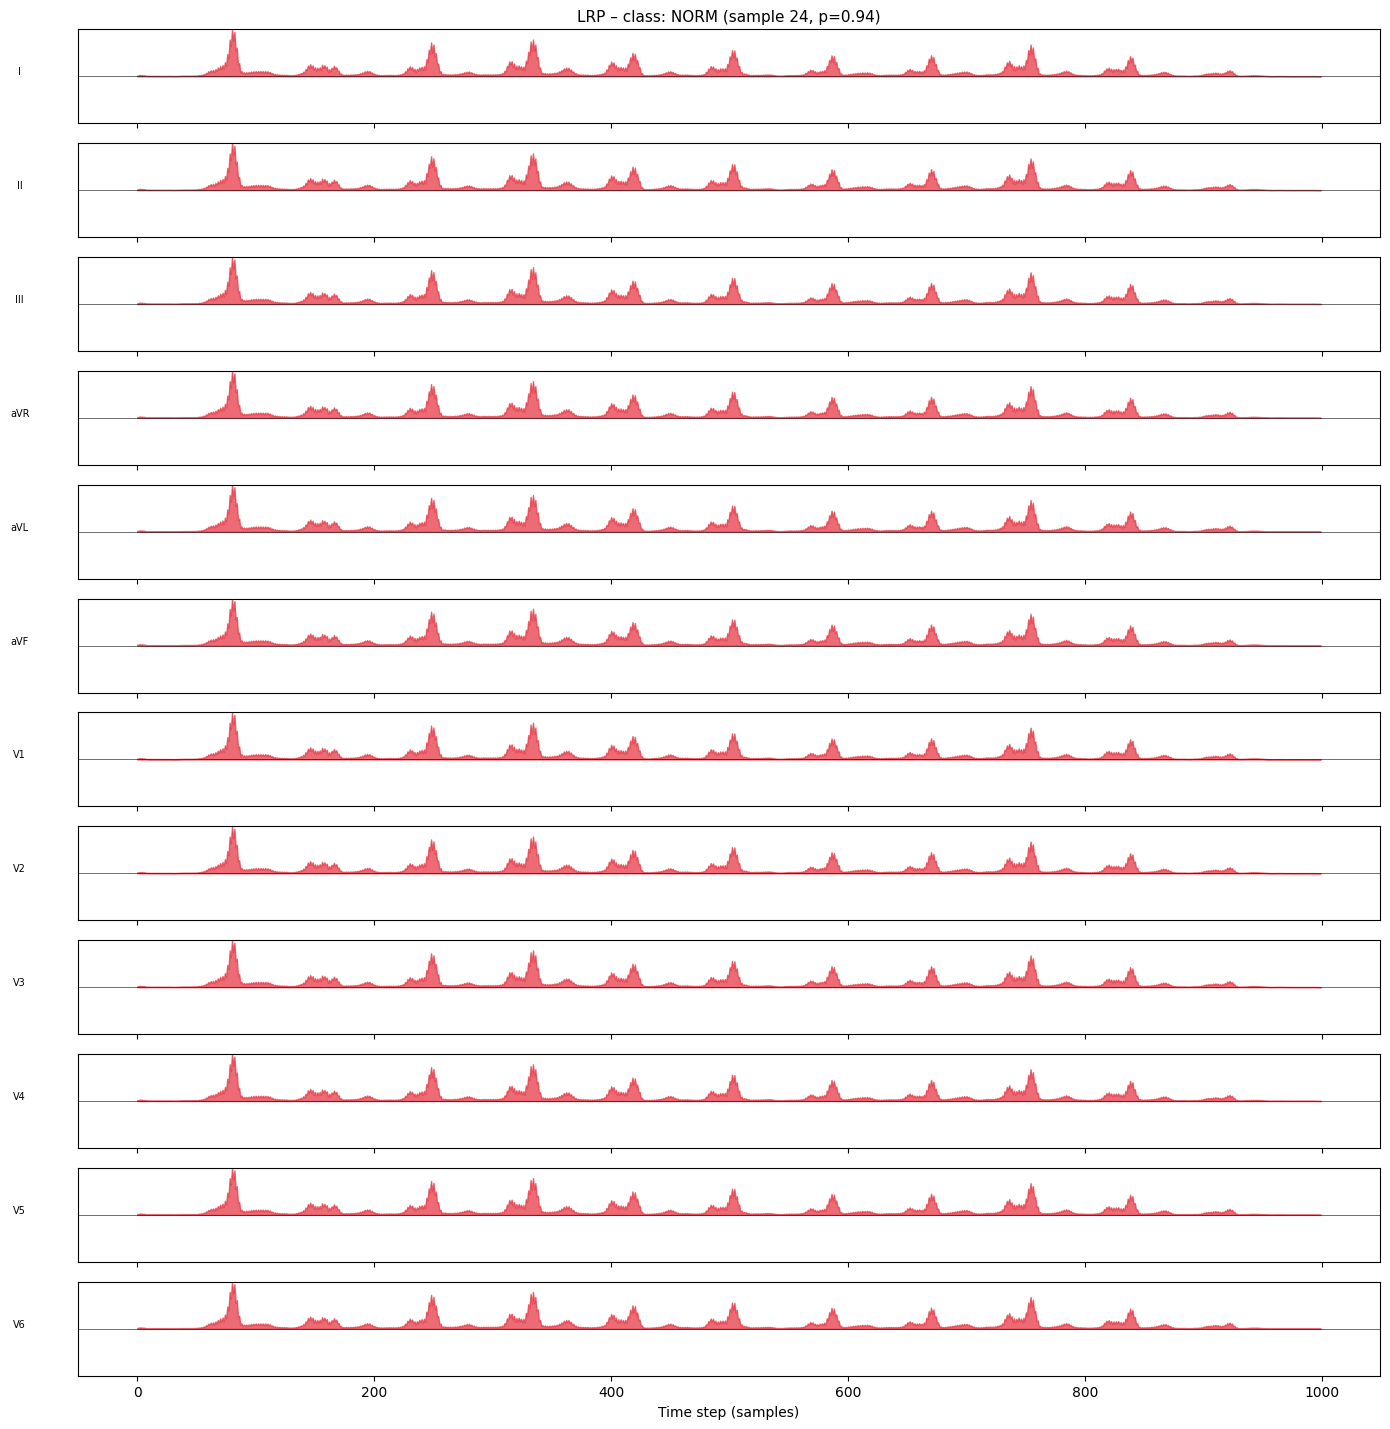

[MI] Sample 41, prob=1.000


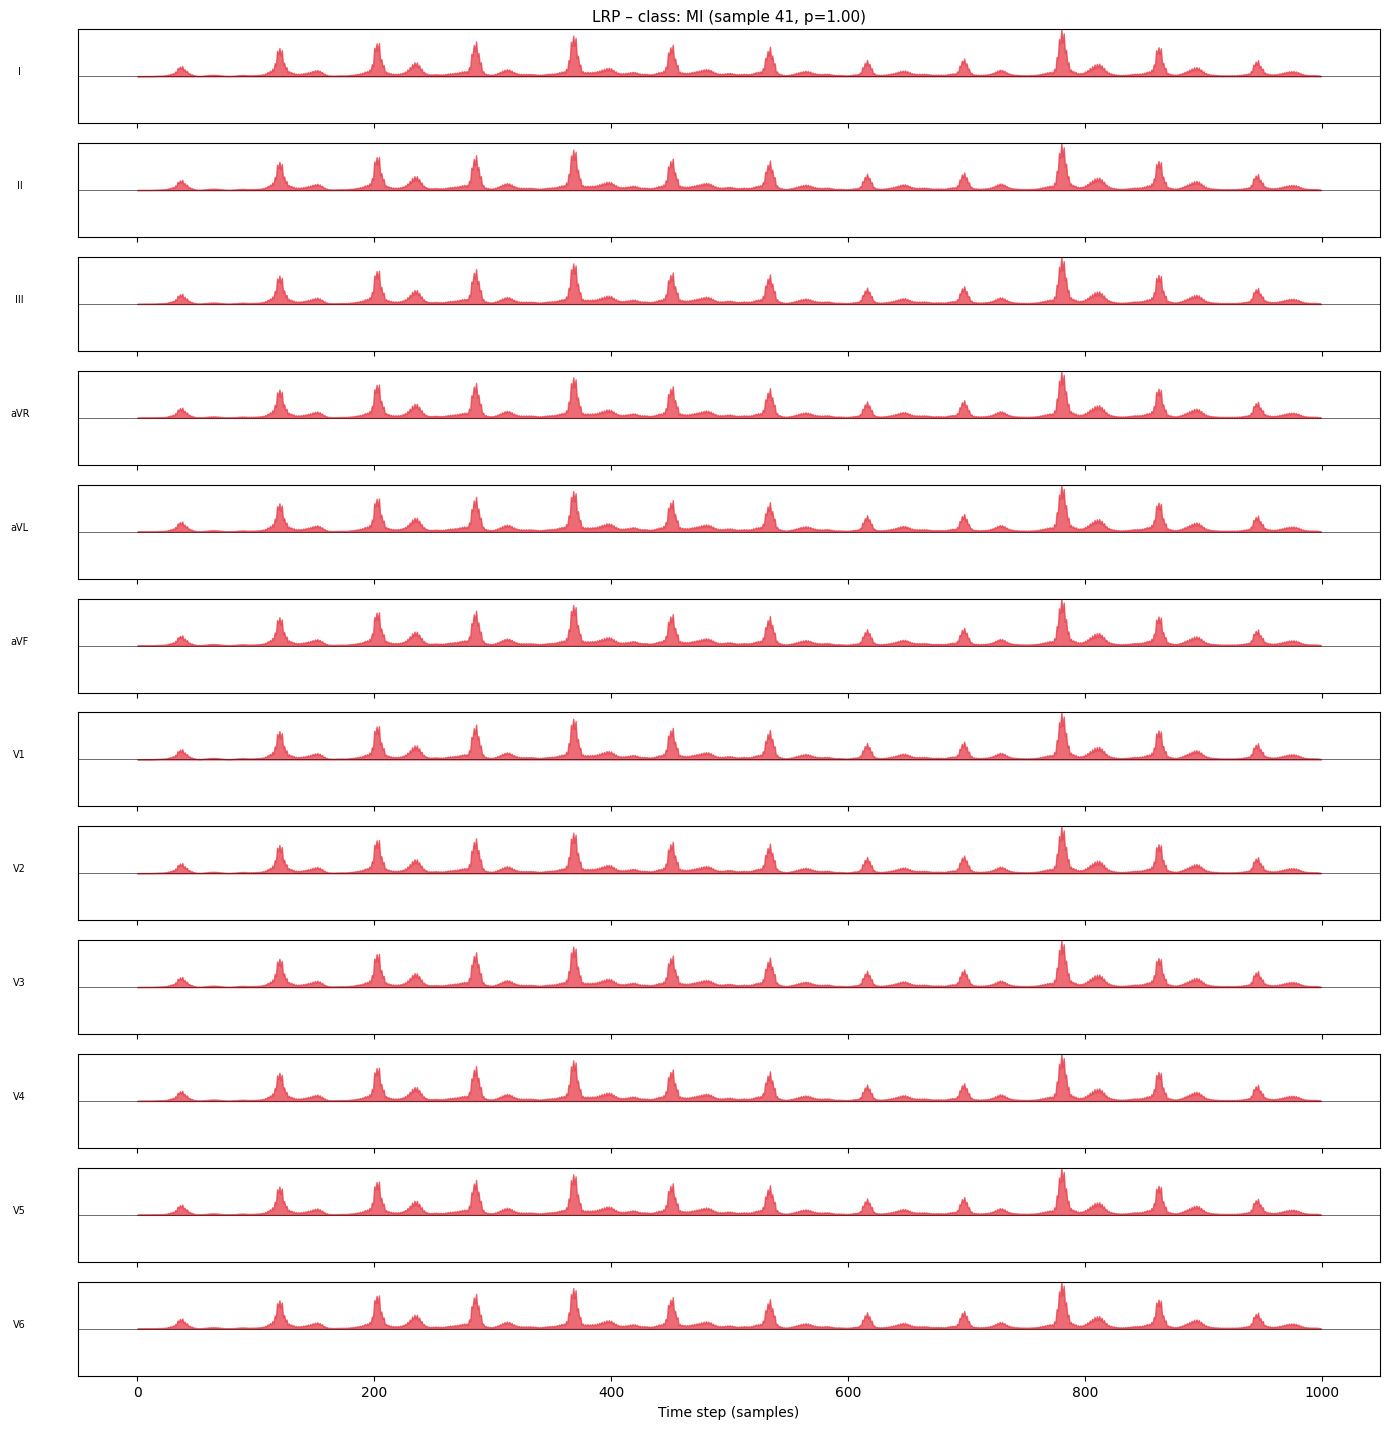

[STTC] Sample 40, prob=0.946


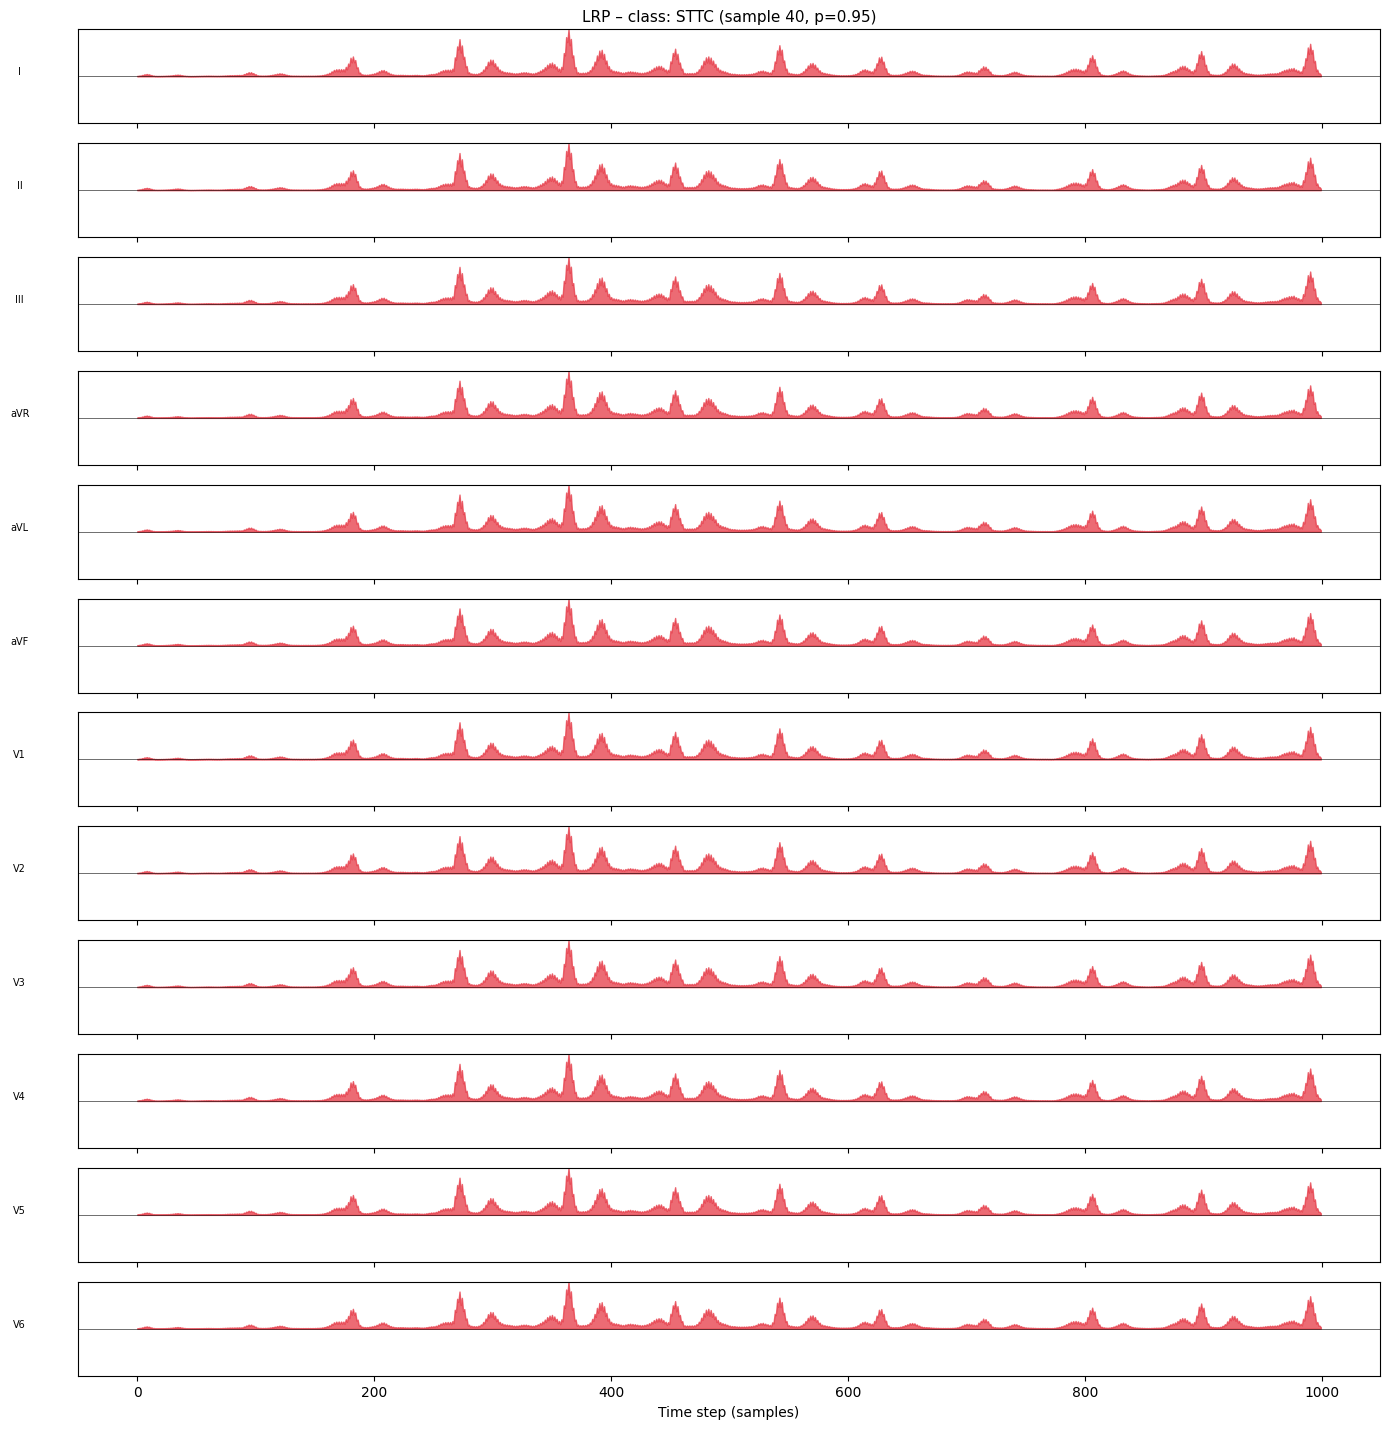

[CD] Sample 0, prob=0.986


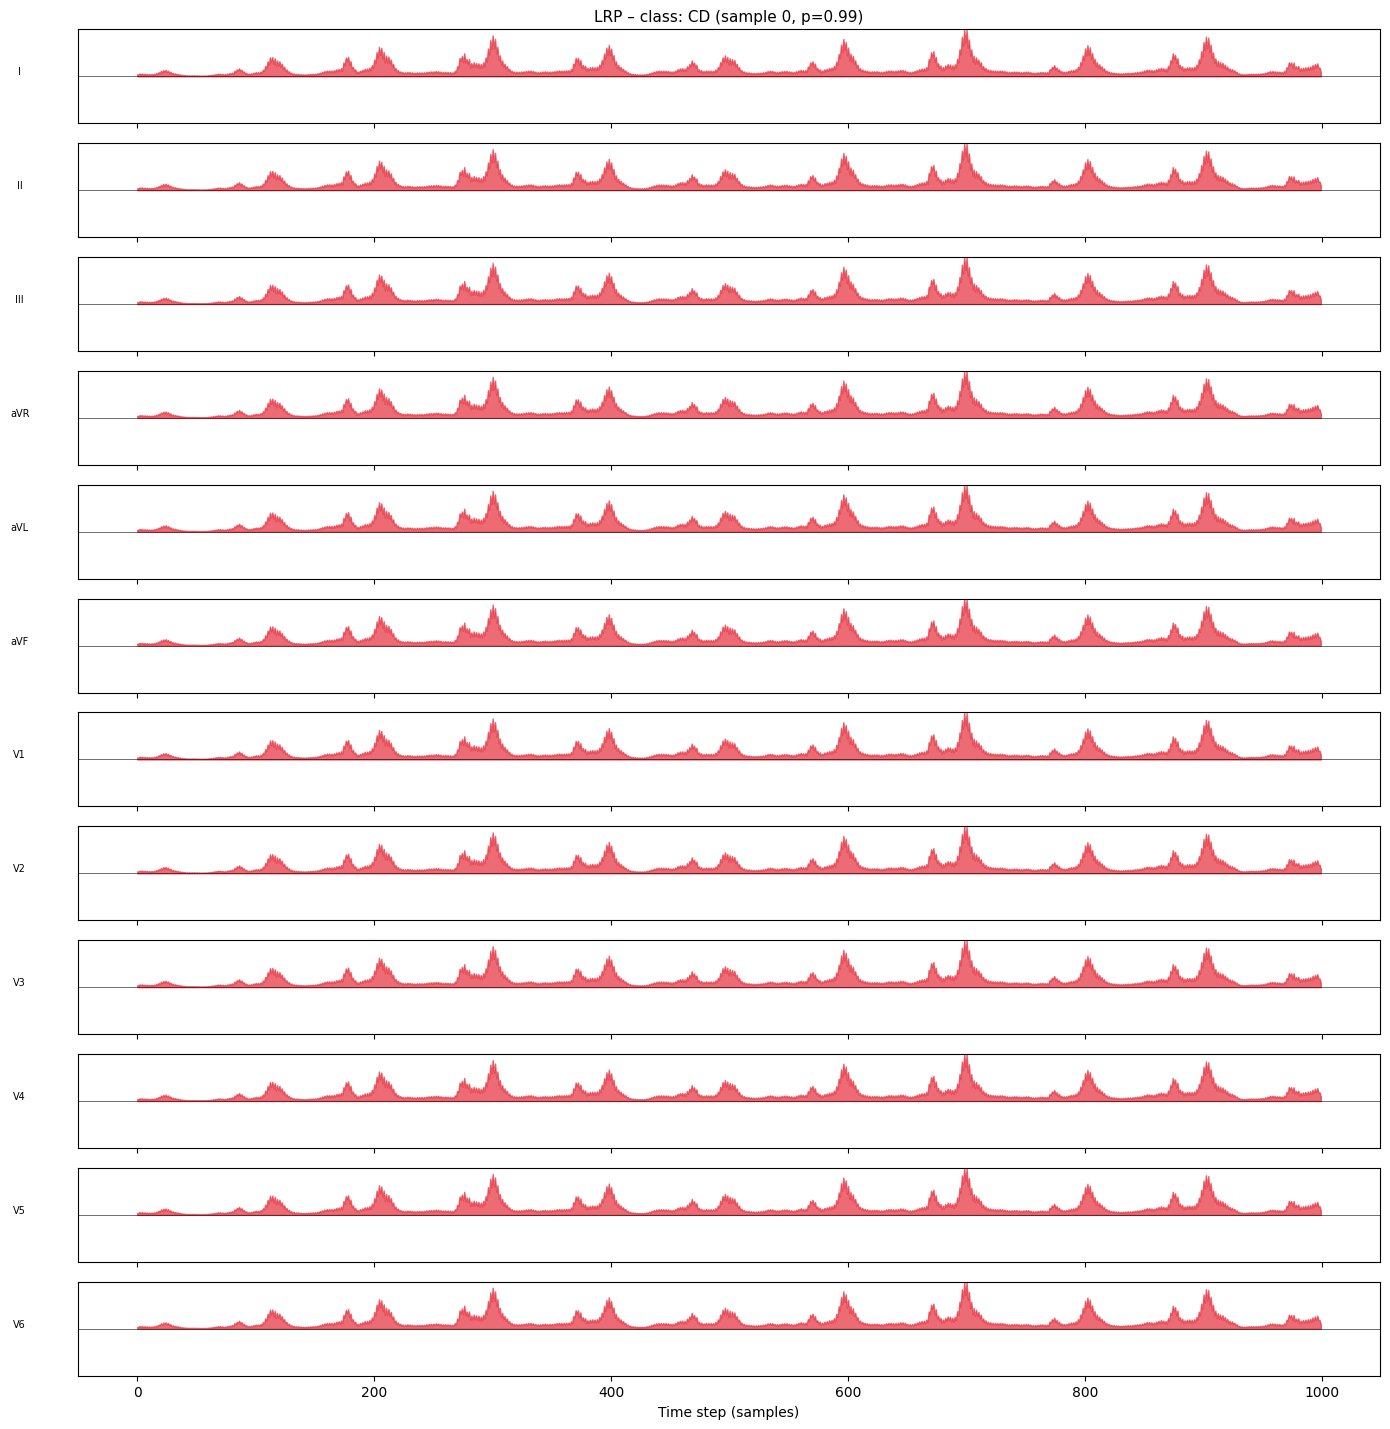

[HYP] Sample 39, prob=0.917


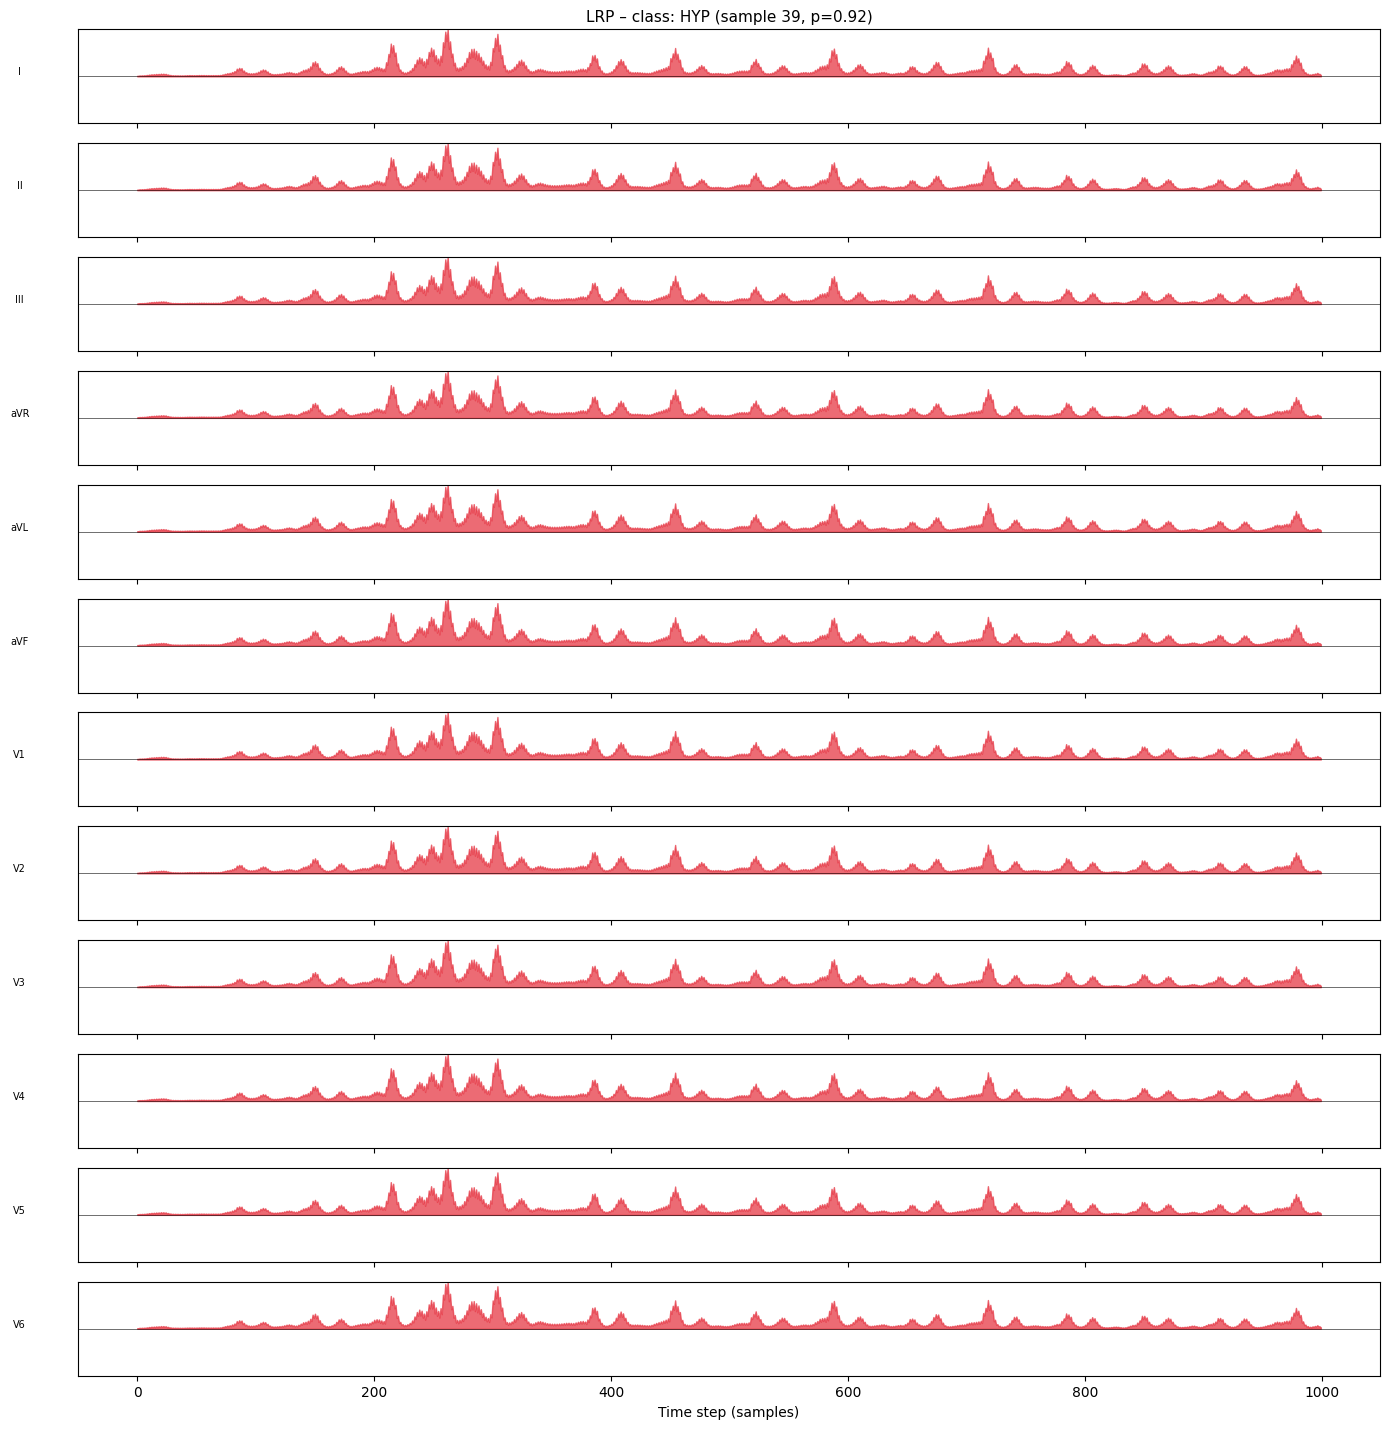

[NORM] Forced sample 6, prob=0.831


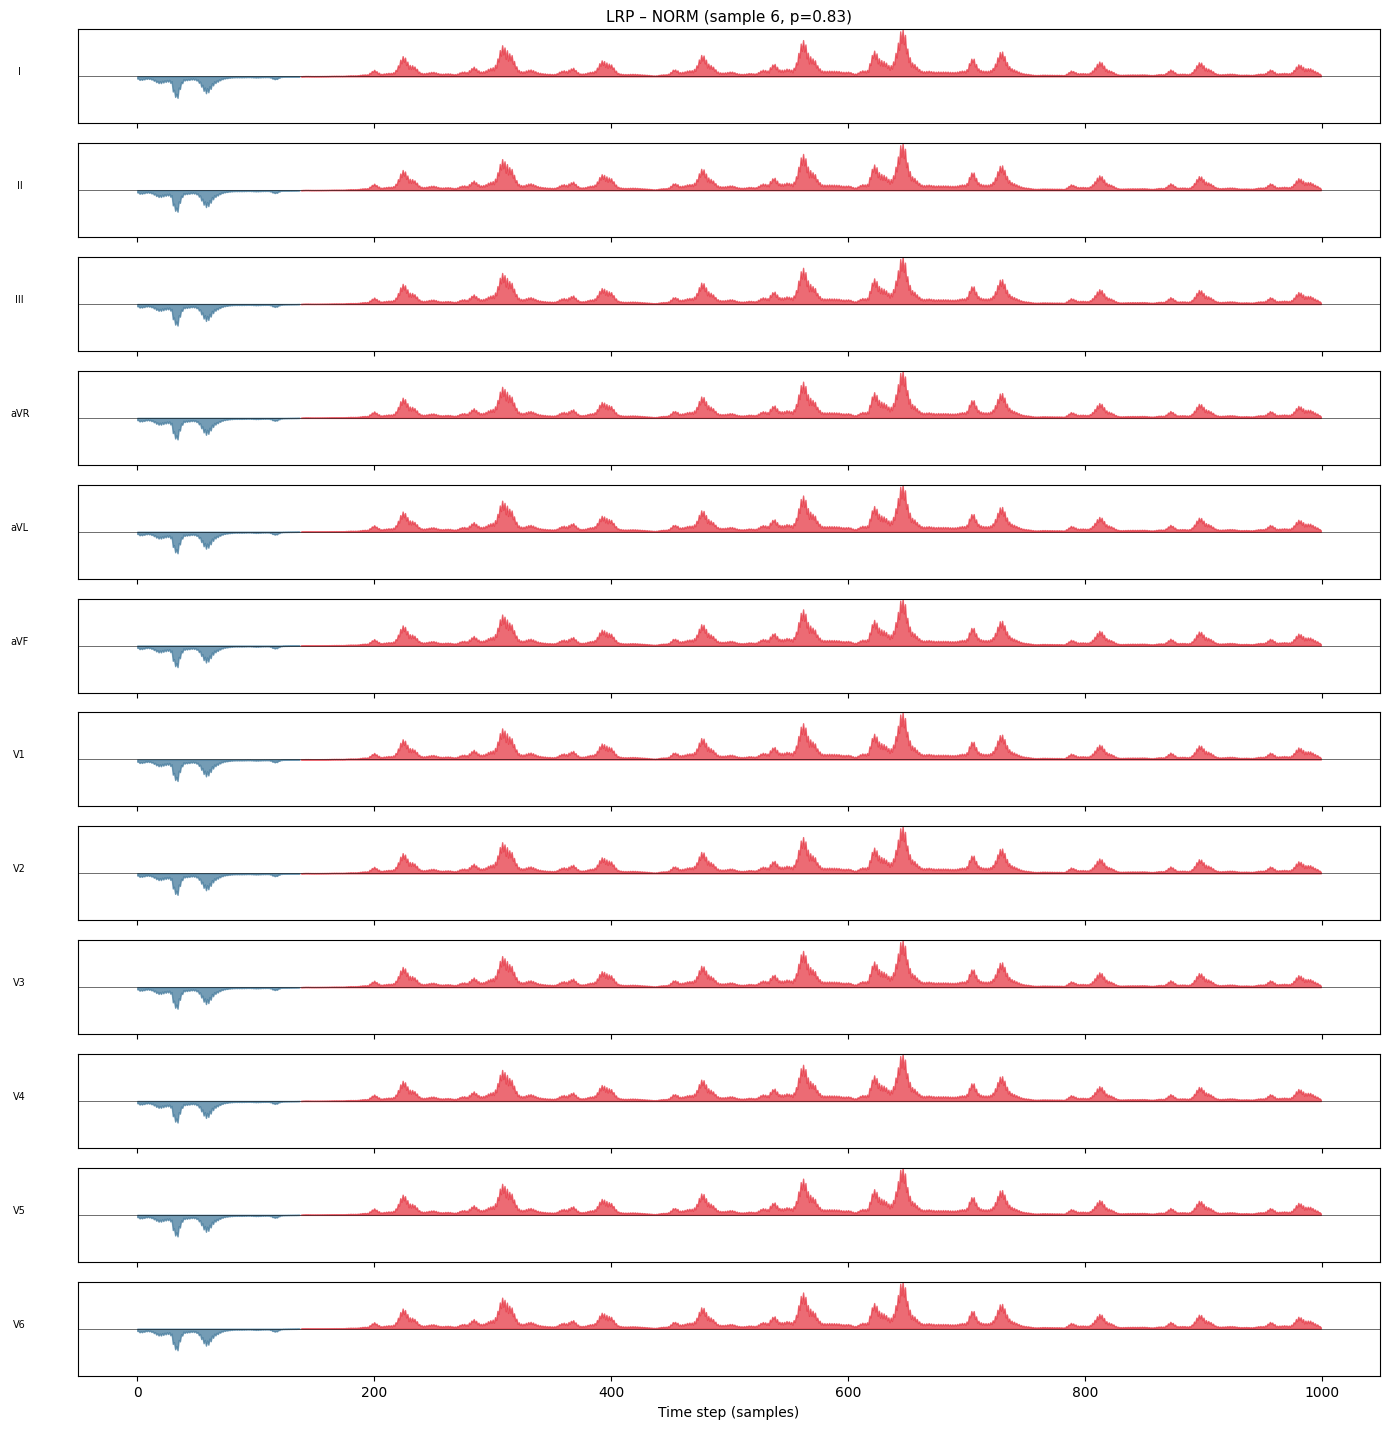

In [41]:
 #── 5.1.1  Per-sample LRP ─────────────────────────────────────────────

"""Find first test sample that is labelled AND predicted confidently."""
def find_confident_sample_ecg(X_test, y_test, class_idx, threshold=0.9):
    for i in range(len(y_test)):
        if y_test[i, class_idx] != 1:
            continue
        ecg_s = torch.tensor(X_test[[i]], dtype=torch.float32).permute(0,2,1)
        with torch.no_grad():
            prob = torch.sigmoid(ecg_only(ecg_s.to(DEVICE)))[0, class_idx].item()
        if prob >= threshold:
            return i, ecg_s, prob
    return None, None, None

for class_idx, class_name in enumerate(CLASS_NAMES):
    idx, ecg_s, prob = find_confident_sample_ecg(X_test, y_test, class_idx)
    if idx is None:
        print(f"[{class_name}] No confident sample found.")
        continue
    print(f"[{class_name}] Sample {idx}, prob={prob:.3f}")
    rel = explain_lrp(ecg_s, class_idx)
    plot_lrp(rel,
             title=f"LRP – class: {class_name} (sample {idx}, p={prob:.2f})",
             save_path=f'../outputs/lrp_{class_name}.png')

# ----------------------------------------
# EXTRA: Force sample 6 for NORM class
# ----------------------------------------

norm_idx = CLASS_NAMES.index("NORM")   # get correct class index
fixed_idx = 6

ecg_fixed = torch.tensor(X_test[[fixed_idx]], dtype=torch.float32).permute(0,2,1)

with torch.no_grad():
    prob_fixed = torch.sigmoid(ecg_only(ecg_fixed.to(DEVICE)))[0, norm_idx].item()

print(f"[NORM] Forced sample {fixed_idx}, prob={prob_fixed:.3f}")

rel_fixed = explain_lrp(ecg_fixed, norm_idx)

plot_lrp(
    rel_fixed,
    title=f"LRP – NORM (sample {fixed_idx}, p={prob_fixed:.2f})",
    save_path='../outputs/lrp_NORM_sample6.png'
)

#### 5.1.2  Mean LRP across classes

NORM: 50 samples averaged
MI: 50 samples averaged
STTC: 50 samples averaged
CD: 50 samples averaged
HYP: 50 samples averaged


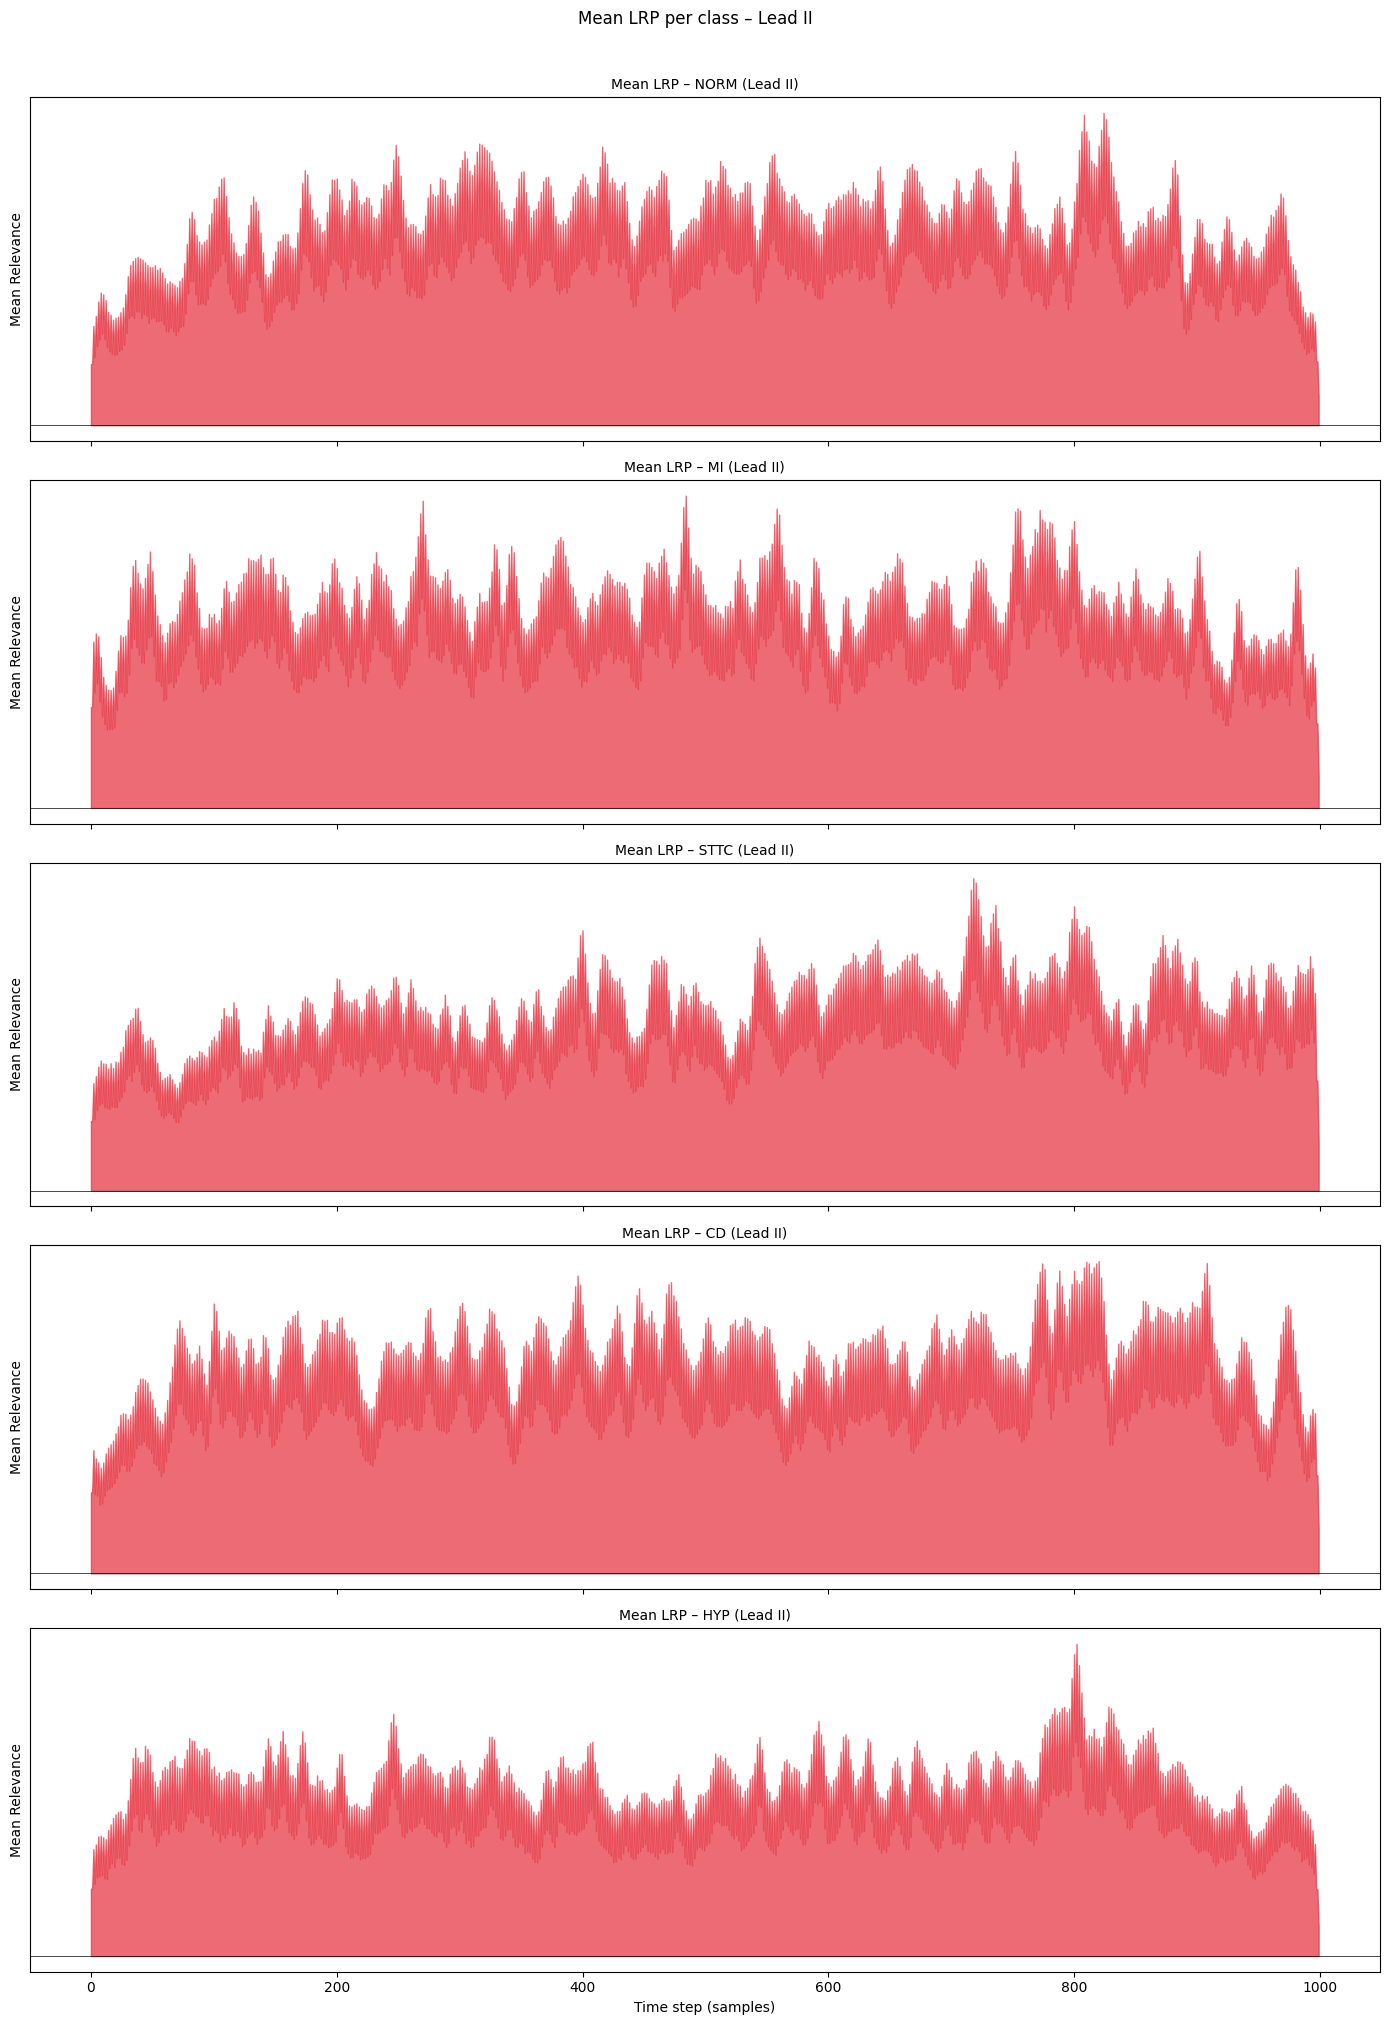

In [34]:
# ── 5.1.2  Mean LRP across classes ───────────────────────────────────
def mean_lrp_ecg(X_test, y_test, class_idx, n_samples=50, threshold=0.7):
    relevances = []
    for i in range(len(y_test)):
        if len(relevances) >= n_samples:
            break
        if y_test[i, class_idx] != 1:
            continue
        ecg_s = torch.tensor(X_test[[i]], dtype=torch.float32).permute(0,2,1)
        with torch.no_grad():
            prob = torch.sigmoid(ecg_only(ecg_s.to(DEVICE)))[0, class_idx].item()
        if prob < threshold:
            continue
        rel = explain_lrp(ecg_s, class_idx)
        max_abs = np.abs(rel).max()
        if max_abs > 0:
            rel = rel / max_abs
        relevances.append(rel)
    if not relevances:
        print(f"No confident samples for {CLASS_NAMES[class_idx]}")
        return None
    print(f"{CLASS_NAMES[class_idx]}: {len(relevances)} samples averaged")
    return np.mean(relevances, axis=0)

fig, axes = plt.subplots(len(CLASS_NAMES), 1,
                          figsize=(14, 4 * len(CLASS_NAMES)), sharex=True)
for class_idx, (class_name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    mean_rel = mean_lrp_ecg(X_test, y_test, class_idx, n_samples=50)
    if mean_rel is None:
        continue
    lead = mean_rel[1]  # Lead II
    ax.fill_between(range(1000), lead,
                    where=(lead > 0), color="#E63946", alpha=0.75)
    ax.fill_between(range(1000), lead,
                    where=(lead < 0), color="#457B9D", alpha=0.75)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"Mean LRP – {class_name} (Lead II)", fontsize=10)
    ax.set_ylabel("Mean Relevance")
    ax.tick_params(left=False, labelleft=False)

axes[-1].set_xlabel("Time step (samples)")
plt.suptitle("Mean LRP per class – Lead II", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/mean_lrp_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 DTD  –  Validate LRP explanations

In [35]:
lrp_rel, dtd_rel, corr = xai.validate_lrp_with_dtd(
    ecg          = ecg_sample,
    target_class = TARGET_CLASS,
    lead_idx     = 1,   # Lead II – most informative for many conditions
    save_path    = '../outputs/dtd_vs_lrp.png'
)
# corr ≥ 0.85 → LRP and DTD agree → explanations are stable
print(f'Pearson r (LRP vs DTD): {corr:.4f}')

TypeError: XAIPipeline.validate_lrp_with_dtd() missing 1 required positional argument: 'meta'

### 5.3 Grad-CAM  –  qualitative / optional

In [ ]:
cam = xai.explain_ecg_gradcam(
    ecg          = ecg_sample,
    target_class = TARGET_CLASS,
    lead_idx     = 1,
    save_path    = '../outputs/gradcam.png'
)

---
## 6. Metadata XAI  –  SHAP

In [ ]:
# Background: random 100 training samples (or use shap.kmeans for speed)
import shap

bg_idx  = np.random.choice(len(meta_train), size=100, replace=False)
bg_meta = meta_train.iloc[bg_idx].values.astype(np.float32)

# KMeans summary is faster for large backgrounds
# bg_meta = shap.kmeans(meta_train.values.astype(np.float32), 50).data

xai.init_shap(background_meta=bg_meta)

In [ ]:
# Explain a batch of test metadata
test_meta_np = meta_test.iloc[:50].values.astype(np.float32)

shap_vals = xai.explain_meta_shap(
    meta_samples   = test_meta_np,
    class_idx      = TARGET_CLASS,
    n_samples      = 100,           # increase for publication-quality
    save_summary   = '../outputs/shap_summary.png',
    save_waterfall = '../outputs/shap_waterfall.png',
    sample_idx     = SAMPLE_IDX,
)

---
## 7. Global PFI  –  Permutation Feature Importance

In [ ]:
# Use entire test set (or a subset for speed)
N_PFI = 500

ecg_pfi  = torch.tensor(X_test[:N_PFI], dtype=torch.float32).permute(0,2,1)
meta_pfi = torch.tensor(meta_test.iloc[:N_PFI].values, dtype=torch.float32)
tgt_pfi  = torch.tensor(y_test[:N_PFI], dtype=torch.float32)

# Metric: macro-AUC  (higher = better, so drop in AUC = importance)
def macro_auc(preds_np, targets_np):
    try:
        return roc_auc_score(targets_np, preds_np, average='macro')
    except Exception:
        return 0.0

meta_imp, lead_imp, mod_imp = xai.run_pfi(
    ecg        = ecg_pfi,
    meta       = meta_pfi,
    targets    = tgt_pfi,
    metric_fn  = macro_auc,
    save_prefix= '../outputs/pfi'
)

print('\nTop metadata features:')
for k, v in sorted(meta_imp.items(), key=lambda x: -x[1]):
    print(f'  {k:15s}: {v:.4f}')

print('\nTop ECG leads:')
for k, v in sorted(lead_imp.items(), key=lambda x: -x[1]):
    print(f'  {k:8s}: {v:.4f}')

print('\nModality comparison:')
for k, v in mod_imp.items():
    print(f'  {k}: {v:.4f}')

---
## 8. Full single-sample dashboard

In [ ]:
probs = xai.explain_sample(
    ecg             = ecg_sample,
    meta            = meta_sample,
    target_class    = TARGET_CLASS,
    background_meta = bg_meta,
    save_path       = '../outputs/xai_dashboard.png'
)
print('Predicted probabilities:', dict(zip(CLASS_NAMES, probs.round(3))))